In [37]:
from pathlib import Path
import numpy as np
import tifffile
import matplotlib.pyplot as plt

files = {
    "bg0":   Path("/Users/sunxiaoyuamanda/Desktop/summer project/9.5/9.5 0 10x stain s1/9.5 0 10x stain s1_MMStack_Pos0.ome.tif"),
    "bg45":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/9.5/9.5 45 10x stain s1/9.5 45 10x stain s1_MMStack_Pos0.ome.tif"),
    "bg90":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/9.5/9.5 90 10x stain s1/9.5 90 10x stain s1_MMStack_Pos0.ome.tif"),
    "bg135": Path("/Users/sunxiaoyuamanda/Desktop/summer project/9.5/9.5 135 10x stain s1/9.5 135 10x stain s1_MMStack_Pos0.ome.tif"),
    "bglcir": Path("/Users/sunxiaoyuamanda/Desktop/summer project/9.5/9.5 left 10x stain s1/9.5 left 10x stain s1_MMStack_Pos0.ome.tif"),
    "bgrcir": Path("/Users/sunxiaoyuamanda/Desktop/summer project/9.5/9.5 right 10x stain s1/9.5 right 10x stain s1_MMStack_Pos0.ome.tif"),

    "dark": Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.29/7.29 dark/7.29 dark_MMStack_Pos0.ome.tif"),
}


for key, path in files.items():
    print(f"{key}: exists={path.exists()}")

bg0: exists=True
bg45: exists=True
bg90: exists=True
bg135: exists=True
bglcir: exists=True
bgrcir: exists=True
dark: exists=True


In [38]:
def print_file_status(file_dict):
    for key, path in file_dict.items():
        print(f"{key}: exists={path.exists()} -> {path}")


def print_mat(name, arr, digits=3):
    fmt = {"float_kind": lambda x: f"{x:.{digits}f}"}
    print(f"{name} =")
    print(np.array2string(np.asarray(arr), formatter=fmt))
    print()

In [39]:
def load_ome_tif(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    with tifffile.TiffFile(path) as tif:
        if len(tif.pages) == 1:
            arr = tif.pages[0].asarray()
        else:
            arr = np.stack([page.asarray() for page in tif.pages], axis=0)

    arr = np.squeeze(arr)
    print(f"{path.name}: shape={arr.shape}, dtype={arr.dtype}")

    if arr.ndim == 2:
        img = arr
    elif arr.ndim == 3:
        print(f"Info: using full stack with shape {arr.shape}")
        img = arr
    else:
        raise ValueError(f"Unsupported image shape: {arr.shape}")

    return img.astype(np.float64)

In [40]:
def load_all_images(file_dict):
    data = {}
    for key, path in file_dict.items():
        data[key] = load_ome_tif(path)
    return data

In [41]:
def split_pol_channels(raw):
    """
    mosaic:
        [ I0,   I135 ]
        [ I45,  I90  ]
    """
    raw = np.asarray(raw)

    if raw.ndim not in (2, 3):
        raise ValueError(f"Expected 2D or 3D image, got shape {raw.shape}")

    H = raw.shape[-2]
    W = raw.shape[-1]
    if (H % 2 != 0) or (W % 2 != 0):
        raise ValueError(f"Image height and width must be even, got shape {raw.shape}")

    if raw.ndim == 2:
        I0   = raw[0::2, 0::2]
        I135 = raw[0::2, 1::2]
        I45  = raw[1::2, 0::2]
        I90  = raw[1::2, 1::2]
    else:
        I0   = raw[:, 0::2, 0::2]
        I135 = raw[:, 0::2, 1::2]
        I45  = raw[:, 1::2, 0::2]
        I90  = raw[:, 1::2, 1::2]

    return I0, I45, I90, I135

In [42]:
def match_dark_shape(raw, dark):
    raw = np.asarray(raw)
    dark = np.asarray(dark, dtype=np.float64)

    if raw.ndim == 2 and dark.ndim == 2:
        return dark

    if raw.ndim == 3 and dark.ndim == 2:
        return dark[None, :, :]

    if raw.ndim == 3 and dark.ndim == 3:
        return dark

    raise ValueError(f"Unsupported raw/dark shapes: raw={raw.shape}, dark={dark.shape}")

In [43]:
def stokes_from_raw(raw, dark, eps=1e-12):
    raw = np.asarray(raw, dtype=np.float64)
    dark = match_dark_shape(raw, dark)

    raw = raw - dark
    raw = np.clip(raw, 0, None)

    I0, I45, I90, I135 = split_pol_channels(raw)

    S0 = 0.5 * (I0 + I45 + I90 + I135)
    S1 = I0  - I90
    S2 = I45 - I135

    return S0, S1, S2


In [44]:
print_file_status(files)
data = load_all_images(files)

bg0: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/9.5/9.5 0 10x stain s1/9.5 0 10x stain s1_MMStack_Pos0.ome.tif
bg45: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/9.5/9.5 45 10x stain s1/9.5 45 10x stain s1_MMStack_Pos0.ome.tif
bg90: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/9.5/9.5 90 10x stain s1/9.5 90 10x stain s1_MMStack_Pos0.ome.tif
bg135: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/9.5/9.5 135 10x stain s1/9.5 135 10x stain s1_MMStack_Pos0.ome.tif
bglcir: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/9.5/9.5 left 10x stain s1/9.5 left 10x stain s1_MMStack_Pos0.ome.tif
bgrcir: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/9.5/9.5 right 10x stain s1/9.5 right 10x stain s1_MMStack_Pos0.ome.tif
dark: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.29/7.29 dark/7.29 dark_MMStack_Pos0.ome.tif
9.5 0 10x stain s1_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
9.5 45 

In [69]:
S_in=stokes_from_raw(data["bg45"], data["dark"])
print(S_in[0].shape)

(1024, 1216)


In [46]:
y, x = 100, 100

print_mat(f"S_in[{y},{x}]", S_in[0][y, x], digits=4)

S_in[100,100] =
536.5000



In [47]:
bright_field = S_in[0]
print("bright_field shape:", bright_field.shape)

bright_field shape: (1024, 1216)


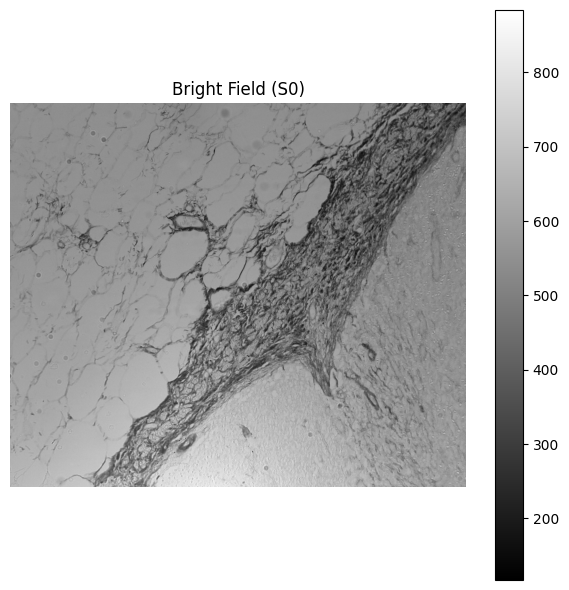

In [48]:
plt.figure(figsize=(6, 6))
plt.imshow(bright_field, cmap='gray')
plt.title("Bright Field (S0)")
plt.axis("off")
plt.colorbar()
plt.tight_layout()
plt.show()

In [49]:
import os
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

In [54]:
save_dir = "9.5 test (stain)"
os.makedirs(save_dir, exist_ok=True)

print("Save directory:", os.path.abspath(save_dir))

Save directory: /Users/sunxiaoyuamanda/Desktop/summer project/9.5 test (stain)


In [70]:
bright_field = S_in[0]
print("bright_field shape:", bright_field.shape)

bright_field shape: (1024, 1216)


In [71]:
bright_field_filename = os.path.join(save_dir, "bright field 45.tif")
def to_float32_image(img):
    return np.asarray(img, dtype=np.float32)

tiff.imwrite(bright_field_filename, to_float32_image(bright_field))

print("Saved bright field TIFF:", bright_field_filename)

Saved bright field TIFF: 9.5 test (stain)/bright field 45.tif
